# 분류와 평가지표

1. 분류란 무엇인가?
2. 여섯가지 알고리즘 비교
3. KNN 
4. 앙상블 - 배깅과 부스팅
5. 평가지표

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import setup
from _ml import build_dataset, FEATURES, SEED, time_split, load_merged

setup()
pd.set_option("display.width", 130)

df = build_dataset()            
train, test, cutoff = time_split(df)

tr = train.sample(15000, random_state=SEED)
te = test.sample(4000, random_state=SEED)

X_train, y_train = tr[FEATURES], tr["target_up"]
X_test, y_test = te[FEATURES], te["target_up"]

print(f" 학습 {len(tr):,}행 ({tr.date.min().date()} ~ {tr.date.max().date()})")
print(f" 테스트 {len(te):,}행 ({te.date.min().date()} ~ {te.date.max().date()})")
print(f"상승 비율   학습 {y_train.mean():.4f} / 테스트 {y_test.mean():.4f}")

[폰트] Malgun Gothic / unicode_minus=False
 학습 15,000행 (2023-10-24 ~ 2026-01-16)
 테스트 4,000행 (2026-01-19 ~ 2026-08-07)
상승 비율   학습 0.4931 / 테스트 0.4825


---
# 1. 분류란 무엇인가?

**범주를 예측하는 문제**다. 

|종류|예|
|---|---|
|이진 분류|상승/하락, 스팸여부, 연체여부...|
|다중 분류|섹터예측, 신용등급(1,2,3,4..)...|

우리는 이진분류를 중점적으로 다루겠다. 
-> 지표가 명확하고 가장 많이 사용하는 형태라서.

수익률, 거래량비율, 이평대비, 변동성 -> up / down

> 오늘 장이 끝나기 전에, 오늘 주식이 오를 것이가를 예측한다.

---
# 2. 여섯 가지 알고리즘

> 사용법 - 모든 알고리즘을 동일하게 사용할 수 있다.
> model = 어떤모델()
> model.fit(X_train, y_train)
> pred = model.predict(X_test)
> score = model.score(X_test, y_test)

|모델|스케일링|속도|해석|성능|
|---|---|---|---|---|
|LogisticRegression|필요|빠름|O|보통|
|DecisionTree|불필요|빠름|O|낮음|
|KNN|필수|예측이느림|△|보통|
|RandomForest|불필요|보통|△|좋음|
|SVM|필요|매우느림|X|그때그때다름|
|GradientBoosting|불필요|느림|△|좋음|

In [4]:
from sklearn.dummy import DummyClassifier #다른 모델 성능을 비교할 기준선을 만드는 분류기
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # 여러개의 알고리즘이 합처진 RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression #선형모델
from sklearn.metrics import accuracy_score, f1_score # accuracy_score(정확도), f1_score(정밀도, 재현률의 평균)
from sklearn.neighbors import KNeighborsClassifier # KNN 모델
from sklearn.pipeline import Pipeline # 데이터 전처리부터 모델 학습과정을 하나로 묶을 수 있게 해주는 도구
from sklearn.preprocessing import StandardScaler # 각 피처의 평균을 0, 표준편차를 1로 만들어 데이터 단위 맞춰주는 전처리 도구
from sklearn.svm import SVC # svm모델
from sklearn.tree import DecisionTreeClassifier # 의사결정나무

# 스케일링이 필요한 모델은 Pipeline으로 묶어준다.
def with_scaler(model):
    return Pipeline([("sc", StandardScaler()), ("m", model)])

# SVM은 데이터 수의 제곱에 비례해 느려짐. 표본을 줄여서 사용.
SVM_N = 3000

models = {
    "DummyClassifier": (DummyClassifier(strategy="most_frequent"), False),
    "LogisticRegression": (with_scaler(LogisticRegression(max_iter=1000, random_state=SEED)), False),
    "DecisionTree(제한)": (DecisionTreeClassifier(max_depth=5, random_state=SEED), False),
    "DecisionTree(제한없음)": (DecisionTreeClassifier(random_state=SEED), False),
    "KNN(k-50)": (with_scaler(KNeighborsClassifier(n_neighbors=50, n_jobs=-1)), False),
    "RandomForest" : (RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1), False),
    "GradientBoosting" : (GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=SEED), False),
    "SVM(표본3천개)" : (with_scaler(SVC(random_state=SEED)), True)
}

rows = []
for name, (model, small) in models.items():
    #SVM만 작은 표본으로 진행
    Xtr = X_train.iloc[:SVM_N] if small else X_train
    ytr = y_train.iloc[:SVM_N] if small else y_train

    t0 = time.perf_counter()
    model.fit(Xtr, ytr)
    fit_time = time.perf_counter() - t0

    pred = model.predict(X_test)
    rows.append({
        "모델": name,
        "학습": model.score(Xtr, ytr),
        "테스트" : accuracy_score(y_test, pred),
        "F1" : f1_score(y_test, pred, zero_division=0),
        "학습시간": fit_time,
    })

result = pd.DataFrame(rows)
print(result.round(4).to_string(index=False))

                모델     학습    테스트     F1   학습시간
   DummyClassifier 0.5069 0.5175 0.0000 0.0010
LogisticRegression 0.5107 0.4805 0.3859 0.0222
  DecisionTree(제한) 0.5219 0.4810 0.5245 0.0432
DecisionTree(제한없음) 1.0000 0.5005 0.4893 0.1606
         KNN(k-50) 0.5672 0.5178 0.4708 0.0132
      RandomForest 0.6105 0.4932 0.4269 0.2587
  GradientBoosting 0.5987 0.4960 0.4434 2.5450
        SVM(표본3천개) 0.5720 0.4915 0.3787 0.1594


### 확인할 떄

**DummyClassifier** - 항상 다수 클래스만 답하는 모델. 이값이 기준이된다. 이것보다 못하면 그 모델은 사용자체가 불가함.

**DecisionTree(제한없음)** - 학습 정확도가 1.0000이다. 학습데이터를 외운거다. 테스트와의 차이가 크다 -> 과적합

**SVM** - 표본이 1/5 수준인데도 느리다. 계산량이 데이터 수의 제곱으로 비례한다. 

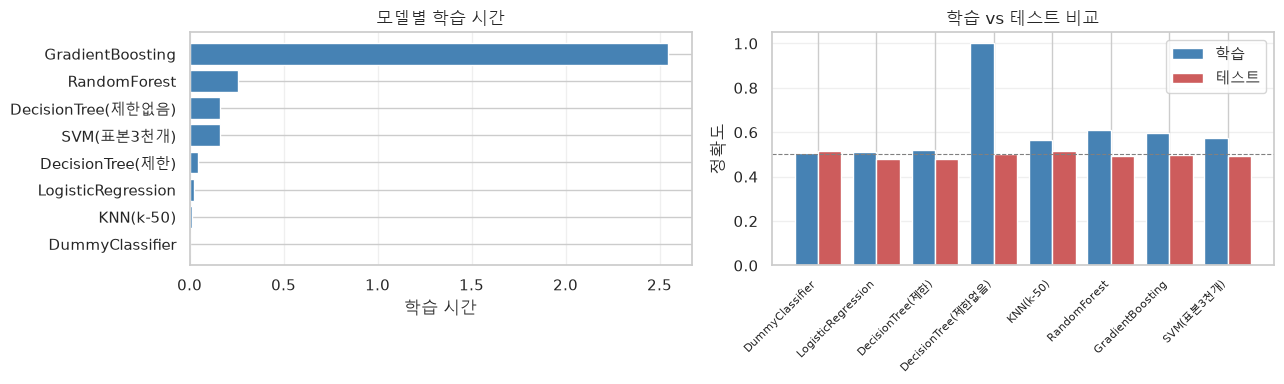

In [5]:
# 학습시간을 그림으로 비교해보자
fig, axes = plt.subplots(1,2, figsize=(13,4))

r = result.sort_values("학습시간")
axes[0].barh(r["모델"], r["학습시간"], color="steelblue")
axes[0].set_xlabel("학습 시간")
axes[0].set_title("모델별 학습 시간")
axes[0].grid(alpha=0.3, axis="x")

#학습 vs 테스트 비교
x = np.arange(len(result))
axes[1].bar(x - 0.2, result["학습"], 0.4, label="학습", color="steelblue")
axes[1].bar(x + 0.2, result["테스트"], 0.4, label="테스트", color="indianred")
axes[1].set_xticks(x) # x축 눈금의 기본위치
axes[1].set_xticklabels(result["모델"], rotation=45, ha="right", fontsize=8)
axes[1].axhline(0.5, color="gray", ls="--", lw=0.8)
axes[1].set_ylabel("정확도")
axes[1].set_title("학습 vs 테스트 비교")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()


# KNN - 가장 가까운 K개의 샘플을 찾아서 다수결로 결정

끼리끼리 모인다. -> K값으로 과적합을 조절할 수 있다.

|장점|단점|
|---|---|
|개념이 가장 단순|예측할 때마다 전체 거리를 계산|
|학습이 사실상 없음|예측시에 데이터가 많으면 느림|
|비선형 경계도 처리|스케일링 필수|

**KNN은 예측시에 계산하므로 학습이 거의 필요없다**
fit()에서는 데이터를 저장만 한다.

In [6]:
# K값을 변경하면서 학습, 테스트 서능을 보자.

ks = [1,3,5,10,15,30,50,100,200,500]

rows = []

for k in ks:
    knn = with_scaler(KNeighborsClassifier(n_neighbors=k, n_jobs=-1))
    knn.fit(X_train, y_train)
    tr_s = knn.score(X_train, y_train)
    te_s = knn.score(X_test, y_test)
    rows.append({"k" : k, "학습" : tr_s, "테스트" : te_s, "차이" : tr_s - te_s})

knn_result = pd.DataFrame(rows)
print(knn_result.round(4).to_string(index=False))

  k     학습    테스트     차이
  1 1.0000 0.5052 0.4948
  3 0.7562 0.4892 0.2669
  5 0.6916 0.4940 0.1976
 10 0.6273 0.5042 0.1230
 15 0.6115 0.5135 0.0980
 30 0.5845 0.5220 0.0625
 50 0.5672 0.5178 0.0494
100 0.5510 0.5110 0.0400
200 0.5334 0.4968 0.0366
500 0.5232 0.4938 0.0294


**k=1에서 학습 정확도가 1.0000이다**

자기 자신이 가장 가까운 이웃이기 때문에 완전히 답을 외우고 푸는 것과 동일하다. -> 전형적인 과적합.

k를 키우면 학습성능이 내려오면서 두값의 차이가 줄어듬. 더 키우면 결국 항상 다수 클래스에 가까워 진다. -> 과소적합



**+ KNN은 가장 가까운 거리를 구하는 것이기 때문에 항상 스케일링이 필수다.**

---
# 앙상블 - 배깅과 부스팅

여러 모델의 의견을 모으는 방식. 랜덤포레스트도 앙상블 방식이다.

|방식|어떻게|대표|
|---|---|---|
|보팅|서로 다른 알고리즘을 결합|직접 만들어서 사용|
|배깅|같은 알고리즘을 데이터를 달리하여 병렬학습|RandomForest|
|부스팅|약한 모델을 순차적으로 학습|XGBoost, LightGBM|

**배깅과 부스팅의 차이**

배깅은 여러 모델이 **동시에 따로**배우고 의경을 모으는 것. 분산을 줄여 과적합을 막는 전략

부스팅은 앞 모델이 **틀린 것을 다음 모델이 집중적으로**배우는 것. 편향을 줄여 성능을 높이는 전략

In [7]:
# 트리하나 -> 배깅 -> 부스팅

models = {
    "DecisionTree(트리1개)": DecisionTreeClassifier(max_depth=6, random_state=SEED),
    "RandomForest(배깅)" : RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1),
    "GradientBoosting(부스팅)" : GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=SEED),
}

rows = []

for name, m in models.items():
    t0 = time.perf_counter()
    m.fit(X_train, y_train)
    el = time.perf_counter() - t0
    rows.append({
        "모델": name,
        "학습": m.score(X_train, y_train),
        "테스트": m.score(X_test, y_test),
        "학습시간": el,
    })

ens = pd.DataFrame(rows)
print(ens.round(4).to_string(index=False))

                   모델     학습    테스트   학습시간
   DecisionTree(트리1개) 0.5279 0.4800 0.0524
     RandomForest(배깅) 0.6105 0.4932 0.2595
GradientBoosting(부스팅) 0.5987 0.4960 2.6951


**왜 여러개가 하나보다 나을까?**

트리 하나는 특정 패턴에 치우칩니다. 서로 다르게 치우친 트리 여러 개의 의견을 모으면 개별 오차를 줄일 수 있다.

**부스팅은 학습이 더 느리다.**

배깅은 병렬처리를 하지만 부스팅은 앞 트리의 결과를 받아서 작업을 진행하기 때문에(순차적) 병렬화가 안된다. 

---
# 5. 정확도만을 기준으로 판단하면?

연체 예측모델을 만들었다. 정확도가 97%다. 좋은모델일까?

> 전체 10,000명 중 연체자 300명(3%)

> 모델이 전원 정상처리하면 -> 9,700을 맞힘 -> 정확도 97% -> 연체자 정확도는 0%

In [8]:
print(f"{'기준선':>10}{'양성 비율':>12}{'전부 음성 정확도':>18}")
print("-"*50)
for th in [0.0,0.01,0.02,0.03,0.04,0.05]:
    ratio = (df["target_ret"] > th).mean()
    print(f"{th:>9.0%}{ratio:>12.2%}{1 - ratio:>18.4f}")

       기준선       양성 비율         전부 음성 정확도
--------------------------------------------------
       0%      48.95%            0.5105
       1%      29.46%            0.7054
       2%      15.30%            0.8470
       3%       6.74%            0.9326
       4%       2.86%            0.9714
       5%       1.38%            0.9862


In [ ]:
from sklearn.metrics import precision_score, recall_score

#수익률 5%초과를 급등으로 지정.
TH_P = 0.05
y_tr = (tr["target_ret"] > TH_P).astype(int)
y_te = (te["target_ret"] > TH_P).astype(int)

models = {
    "Dummy(전부아니다)" : DummyClassifier(strategy="most_frequent"),
    "RandomForest" : RandomForestClassifier(n_estimators=100, max_depth=6, 
                                            random_state=SEED, n_jobs=-1),
    "RandomForest(balanced)" : RandomForestClassifier(n_estimators=100, max_depth=6, 
                                              random_state=SEED, n_jobs=-1, 
                                              class_weight="balanced"),
}

rows = []
for name, m in models.items():
    m.fit(X_train, y_tr)
    p = m.predict(X_test)
    rows.append({
        "모델" : name,
        "정확도" : accuracy_score(y_te, p),
        "정밀도" : precision_score(y_te, p, zero_division=0),
        "재현율" : recall_score(y_te, p, zero_division=0),
        "F1" : f1_score(y_te, p, zero_division=0),
    })

print(pd.DataFrame(rows).round(4).to_string(index=False))

                    모델    정확도   정밀도    재현율     F1
          Dummy(전부아니다) 0.9868 0.000 0.0000 0.0000
          RandomForest 0.9868 0.000 0.0000 0.0000
RandomForest(balanced) 0.5678 0.015 0.4906 0.0292


**전부 아니다**라고 답한 더미모델이 정확도가 98%이상이다.

그런데 재현율은 0이다. -> 찾고싶은 값은 한개도 못찾았다.

연체,불량,질병,이상거래... 실무에서 중요한 문제는 대부분 불균형데이터가 많다. -> 정확도가 높은 것은 아무 의미가 없다.

**class_weight="balanced"** 를 넣으면

소수 클래스에 가중치를 줘서 재현율이 올라간다. 대신 정확도와 정밀도가 떨어진다. 한족을 올리면 다른 한쪽이 내려간다.

가장 간단하게 불균형데이터를 대응하는 방법이다.

---
# 혼동행렬 - 모든 지표를 만드는 기준값

True / False -> 예측이 정답이랑 일치했냐?
Positive / Negative -> 모델이 무엇으로 예측했냐?

TP -> 맞다고 했고 맞았다.

FP -> 맞았다고 했고 틀렸다.

FN -> 틀렸다고 했고 틀렸다.

TN -> 틀렸다고 했고 맞았다.

교안에서 그림 확인.

---
# 정밀도, 재형율, F1

|지표|계산|질문|
|---|---|---|
|정확도|(TP + TN) / 전체|전체 중 얼마나 맞혔냐?|
|정밀도(Precision)|TP / (TP + FP)|맞았다고 한것 중 실제로 그러한 값은?|
|재현율(Recall)|TP / (TP+FN)|진짜 맞은 것 중에 맞춘 것은?|
|F1|정밀도, 재형율을 조화롭게 평균|둘의 균형|


정밀도 -> 분모가 "예측" 내가 실제로 잡은 것
재현율 -> 분모가 "실제" 내가 실제로 잡은 것

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_te, p, zero_division=0))